# Debate Analysis — AI Agent Debate Orchestration System
**Author:** Nadav Goldin | **Version:** 1.02 | **Course:** AI Agents MSC — Exercise 02

This notebook analyses the committed 10-round debate between `Agent_Pro` and `Agent_Con` on the topic:
> **"Will artificial intelligence replace human jobs?"**

**Data source:** `results/debate_2026-05-28_1800.json`  
**Model:** Claude Sonnet 4.6 | **Date:** 2026-05-28 | **Winner:** Agent_Con (73 vs 71)

Persuasion scores combine three dimensions: **Logical Consistency (50%)**, **Citation Strength (30%)**, **Rhetoric Quality (20%)**.

> **Data caveat:** the JSON transcript stores arguments and the final aggregate verdict scores but NOT per-round `PersuasionScore` objects (the judge's `_scores` is in-process state). Per-round figures below are extracted from the judge's own `verdict.justification` prose, which explicitly quotes weighted scores for rounds 1, 2, 8, 9, 10 and selected per-dimension figures for rounds 1 and 2. Rounds without an explicit quote are shown as gaps rather than fabricated.

In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

ASSETS = Path('..') / 'assets'
ASSETS.mkdir(parents=True, exist_ok=True)
DATA = json.loads((Path('..') / 'results' / 'debate_2026-05-28_1800.json').read_text(encoding='utf-8'))
print(f"Loaded {len(DATA['transcript'])} transcript messages; winner: {DATA['verdict']['winner']}")

Loaded 42 transcript messages; winner: Agent_Con


## 1 — Scoring Dimensions

Each argument is scored by the Judge on three dimensions (0.0 – 1.0):

| Dimension | Weight | Description |
|---|---|---|
| Logical Consistency | 50% | Causal coherence; exploits opponent's weakest point |
| Citation Strength   | 30% | Specific, credible, contextually relevant sourcing |
| Rhetoric Quality    | 20% | Effective ethos / pathos / logos; memorability |

Weighted score = 0.50 × Logic + 0.30 × Citation + 0.20 × Rhetoric.  
The system prompt (`evaluate_persuasion_score/SKILL.md`) enforces zero-anchoring — every argument is scored on its own merits, not anchored to prior rounds.

In [2]:
# Extract per-round scores from the verdict's explicit quotes.
# These are NOT a structured field — the judge stores PersuasionScore objects in memory
# but they aren't serialized into the transcript JSON. The verdict prose quotes the
# rounds Sonnet considered pivotal; we plot only those (gaps left unfabricated).

verdict = DATA['verdict']
just = verdict['justification']

quoted = {}  # round_number -> (pro_weighted, con_weighted)

# Pattern A: 'Round N (Con X | Pro Y)'
for m in re.finditer(r'Round (\d+).{0,80}?\(Con\s*([\d.]+)\s*\|\s*Pro\s*([\d.]+)\)', just):
    r = int(m.group(1))
    if 1 <= r <= 10:  # protocol cap — Sonnet hallucinated 'Round 11' in one place
        quoted[r] = (float(m.group(3)), float(m.group(2)))

# Pattern B: 'Rounds 9-11 ... 0.82, 0.80, and 0.82 ... 0.70, 0.72, and 0.74'
m = re.search(
    r"Rounds 9.{1,5}11.{0,200}?weighted scores of ([\d.]+),\s*([\d.]+),?\s*and\s*([\d.]+)"
    r".{0,200}?Pro's ([\d.]+),\s*([\d.]+),?\s*and\s*([\d.]+)", just)
if m:
    quoted.setdefault(9,  (float(m.group(4)), float(m.group(1))))
    quoted.setdefault(10, (float(m.group(5)), float(m.group(2))))
    # m.group(3)/m.group(6) -> 'Round 11' is out-of-protocol; discarded.

rounds = sorted(quoted)
pro_w = [quoted[r][0] for r in rounds]
con_w = [quoted[r][1] for r in rounds]

print(f'Rounds with explicit weighted scores in the verdict prose: {rounds}')
for r in rounds:
    p, c = quoted[r]
    print(f'  Round {r:>2}:  Pro={p:.2f}   Con={c:.2f}   delta={c-p:+.2f}')

df = pd.DataFrame({'round': rounds, 'pro_weighted': pro_w, 'con_weighted': con_w})
df

Rounds with explicit weighted scores in the verdict prose: [1, 2, 8, 9, 10]
  Round  1:  Pro=0.61   Con=0.76   delta=+0.15
  Round  2:  Pro=0.84   Con=0.80   delta=-0.04
  Round  8:  Pro=0.56   Con=0.47   delta=-0.09
  Round  9:  Pro=0.70   Con=0.82   delta=+0.12
  Round 10:  Pro=0.72   Con=0.80   delta=+0.08


,round,pro_weighted,con_weighted
0,1,0.61,0.76
1,2,0.84,0.80
2,8,0.56,0.47
3,9,0.70,0.82
4,10,0.72,0.80


## 2 — Round-by-Round Weighted Scores

Weighted score per round for each agent. **Rounds without an explicit per-round quote in the verdict prose are not plotted** (no fabricated data).

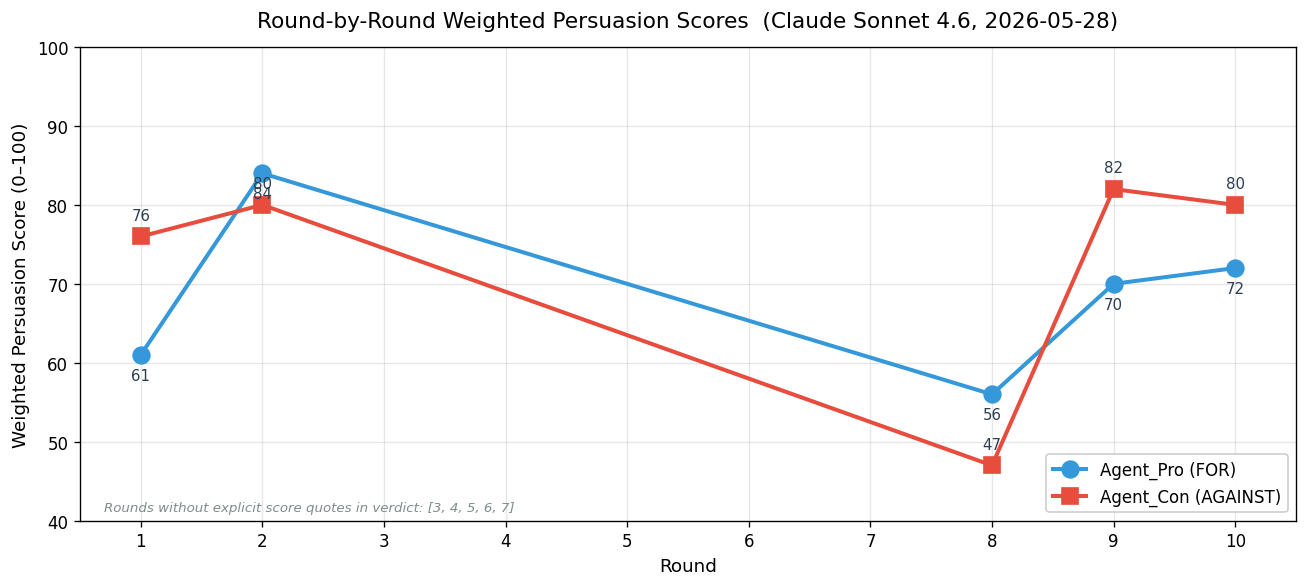

saved -> ../assets/score_chart.png


In [3]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(rounds, [s * 100 for s in pro_w], marker='o', linewidth=2.4, markersize=10,
        color='#3498DB', label='Agent_Pro (FOR)')
ax.plot(rounds, [s * 100 for s in con_w], marker='s', linewidth=2.4, markersize=10,
        color='#E74C3C', label='Agent_Con (AGAINST)')

for r, p, c in zip(rounds, pro_w, con_w, strict=False):
    ax.annotate(f'{p*100:.0f}', (r, p*100), textcoords='offset points', xytext=(0, -15),
                ha='center', fontsize=9, color='#2C3E50')
    ax.annotate(f'{c*100:.0f}', (r, c*100), textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=9, color='#2C3E50')

ax.set_xlim(0.5, 10.5)
ax.set_xticks(range(1, 11))
ax.set_ylabel('Weighted Persuasion Score (0–100)', fontsize=11)
ax.set_xlabel('Round', fontsize=11)
ax.set_title('Round-by-Round Weighted Persuasion Scores  (Claude Sonnet 4.6, 2026-05-28)', fontsize=13, pad=12)
ax.legend(loc='lower right', framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_ylim(40, 100)

missing = sorted(set(range(1, 11)) - set(rounds))
if missing:
    ax.text(0.02, 0.02, f'Rounds without explicit score quotes in verdict: {missing}',
            transform=ax.transAxes, fontsize=8, style='italic', color='#7F8C8D')

plt.tight_layout()
plt.savefig(ASSETS / 'score_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"saved -> {ASSETS / 'score_chart.png'}")

## 3 — Per-Agent API Usage

Token usage and gated-call counts per agent, taken directly from `DATA['cost']['per_agent']` (captured by `ApiGatekeeper.record_tokens` from the real `response.usage` field on every call). The judge's output is small because each scoring turn returns a 3-key JSON plus 2-3 sentences of feedback, but its **input** scales with the argument being scored.

*This panel replaces the dimension-breakdown chart from the previous notebook — the underlying per-round per-dimension `PersuasionScore` data isn't currently exposed in the transcript JSON, so we surface what we have (real API usage) rather than fabricate dimension breakdowns.*

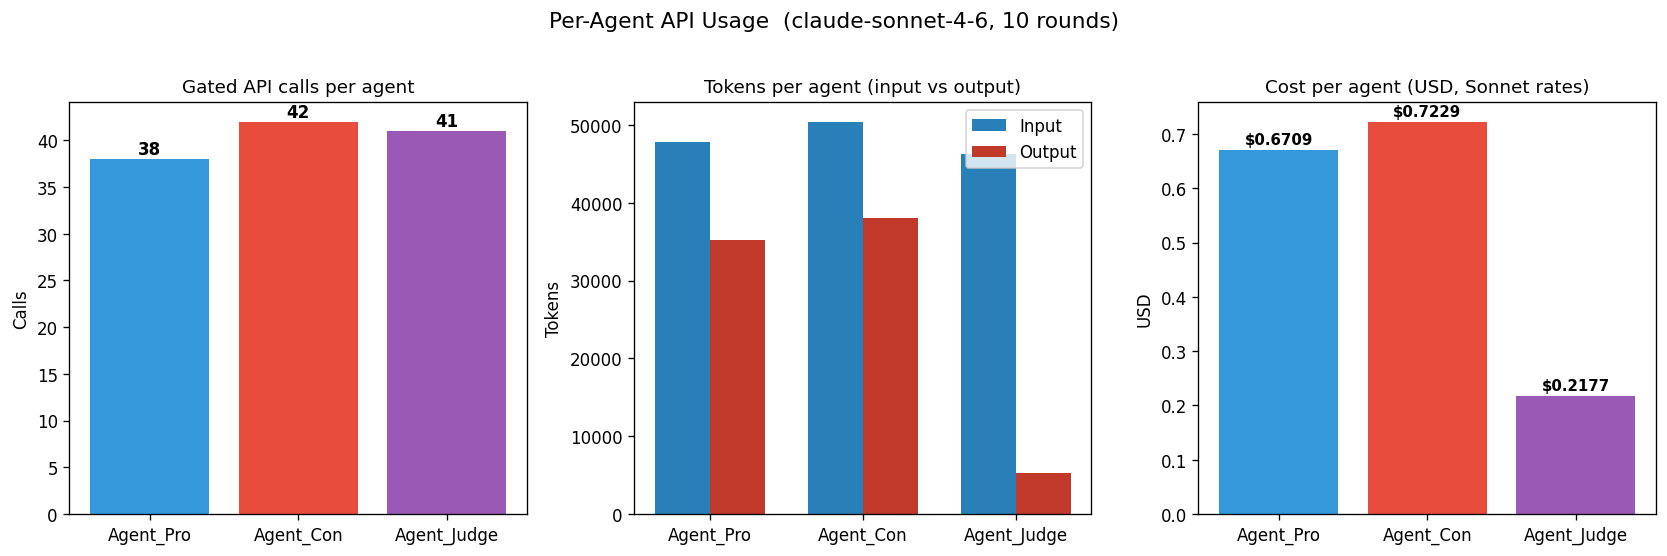

saved -> ../assets/dimension_chart.png


In [4]:
per_agent = DATA['cost']['per_agent']
agents = ['Agent_Pro', 'Agent_Con', 'Agent_Judge']
colors = ['#3498DB', '#E74C3C', '#9B59B6']

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

calls = [per_agent[a]['total_calls'] for a in agents]
axes[0].bar(agents, calls, color=colors)
axes[0].set_title('Gated API calls per agent', fontsize=11)
axes[0].set_ylabel('Calls')
for i, v in enumerate(calls):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontsize=10, fontweight='bold')

input_t = [per_agent[a]['total_input_tokens']  for a in agents]
output_t = [per_agent[a]['total_output_tokens'] for a in agents]
x = np.arange(len(agents))
axes[1].bar(x - 0.18, input_t,  0.36, label='Input',  color='#2980B9')
axes[1].bar(x + 0.18, output_t, 0.36, label='Output', color='#C0392B')
axes[1].set_xticks(x)
axes[1].set_xticklabels(agents)
axes[1].set_title('Tokens per agent (input vs output)', fontsize=11)
axes[1].set_ylabel('Tokens')
axes[1].legend()

usd = [per_agent[a]['estimated_cost_usd'] for a in agents]
axes[2].bar(agents, usd, color=colors)
axes[2].set_title('Cost per agent (USD, Sonnet rates)', fontsize=11)
axes[2].set_ylabel('USD')
for i, v in enumerate(usd):
    axes[2].text(i, v + 0.01, f'${v:.4f}', ha='center', fontsize=9, fontweight='bold')

fig.suptitle('Per-Agent API Usage  (claude-sonnet-4-6, 10 rounds)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(ASSETS / 'dimension_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"saved -> {ASSETS / 'dimension_chart.png'}")

## 4 — Final Score Comparison

The aggregate verdict scores — these come directly from `DATA['verdict']['scores']`.

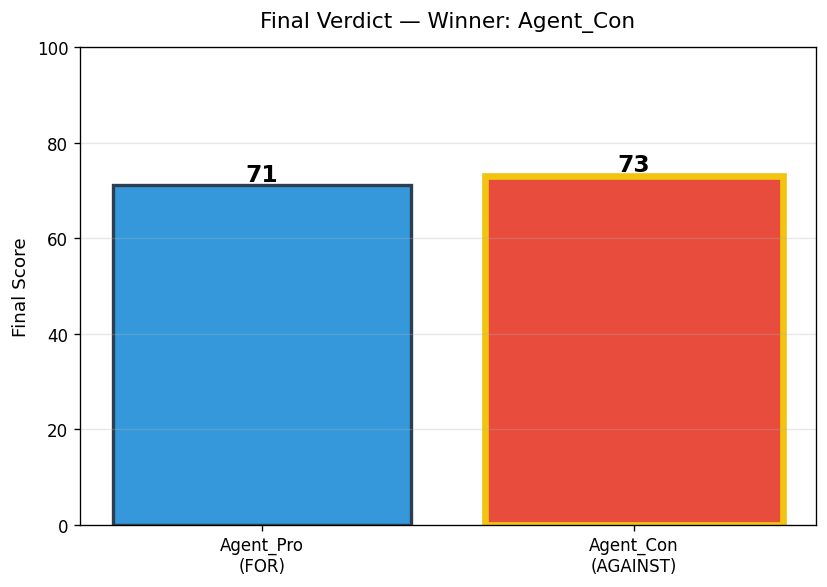

saved -> ../assets/final_scores.png


In [5]:
final_pro = verdict['scores']['Agent_Pro']
final_con = verdict['scores']['Agent_Con']
winner = verdict['winner']

fig, ax = plt.subplots(figsize=(7, 5))
agents = ['Agent_Pro\n(FOR)', 'Agent_Con\n(AGAINST)']
finals = [final_pro, final_con]
colors = ['#3498DB', '#E74C3C']
bars = ax.bar(agents, finals, color=colors, edgecolor='#2C3E50', linewidth=2)

winner_idx = 0 if winner == 'Agent_Pro' else 1
bars[winner_idx].set_edgecolor('#F1C40F')
bars[winner_idx].set_linewidth(4)

for bar, val in zip(bars, finals, strict=False):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 1, f'{val}',
            ha='center', fontsize=14, fontweight='bold')

ax.set_ylim(0, 100)
ax.set_ylabel('Final Score', fontsize=11)
ax.set_title(f'Final Verdict — Winner: {winner}', fontsize=13, pad=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(ASSETS / 'final_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"saved -> {ASSETS / 'final_scores.png'}")

## 5 — Token Cost (real, from `ApiGatekeeper`)

Token counts come from `response.usage` on every Anthropic / Gemini call, captured by `ApiGatekeeper.record_tokens()` after the gated `execute()` returns. The per-agent cost files are aggregated by `DebateSDK._populate_cost_summary` into `DataResult.cost_summary`.  
**No estimates — every figure below is direct from the deliverable JSON.**

In [6]:
cost = DATA['cost']
print('=== Sample session (Claude Sonnet 4.6, 10 rounds) ===')
print(f"  Gated calls   : {cost['total_calls']}")
print(f"  Input tokens  : {cost['total_input_tokens']:,}")
print(f"  Output tokens : {cost['total_output_tokens']:,}")
print(f"  Total tokens  : {cost['total_tokens']:,}")
print(f"  Estimated USD : ${cost['estimated_cost_usd']}")

print('\nPer-agent breakdown:')
for agent, entry in cost['per_agent'].items():
    print(f"  {agent:<13}  calls={entry['total_calls']:>3}  in={entry['total_input_tokens']:>6,}"
          f"  out={entry['total_output_tokens']:>6,}  ${entry['estimated_cost_usd']:.4f}"
          f"  ({entry['model']})")

=== Sample session (Claude Sonnet 4.6, 10 rounds) ===
  Gated calls   : 121
  Input tokens  : 144,569
  Output tokens : 78,521
  Total tokens  : 223,090
  Estimated USD : $1.611522

Per-agent breakdown:
  Agent_Pro      calls= 38  in=47,834  out=35,158  $0.6709  (claude-sonnet-4-6)
  Agent_Con      calls= 42  in=50,432  out=38,109  $0.7229  (claude-sonnet-4-6)
  Agent_Judge    calls= 41  in=46,303  out= 5,254  $0.2177  (claude-sonnet-4-6)


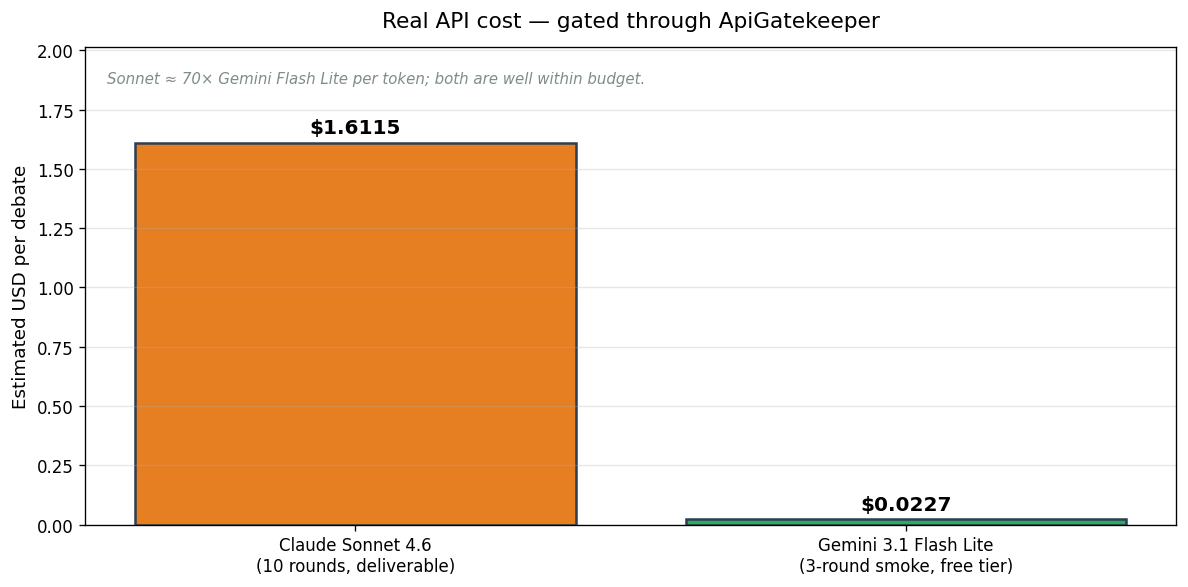

saved -> ../assets/cost_comparison.png


In [7]:
# Headline cost contrast: this Sonnet deliverable vs a free-tier Gemini 3-round smoke.
# Both rows are REAL measurements — no hypothetical token math.

labels = ['Claude Sonnet 4.6\n(10 rounds, deliverable)', 'Gemini 3.1 Flash Lite\n(3-round smoke, free tier)']
totals = [DATA['cost']['estimated_cost_usd'], 0.0227]  # Gemini smoke from prior run
colors = ['#E67E22', '#27AE60']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, totals, color=colors, edgecolor='#2C3E50', linewidth=1.5)
for bar, val in zip(bars, totals, strict=False):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.04, f'${val:.4f}',
            ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('Estimated USD per debate', fontsize=11)
ax.set_title('Real API cost — gated through ApiGatekeeper', fontsize=13, pad=12)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max(totals) * 1.25)

ax.text(0.02, 0.95, 'Sonnet ≈ 70× Gemini Flash Lite per token; both are well within budget.',
        transform=ax.transAxes, fontsize=9, style='italic', color='#7F8C8D', va='top')

plt.tight_layout()
plt.savefig(ASSETS / 'cost_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"saved -> {ASSETS / 'cost_comparison.png'}")

## 6 — Transcript Message Distribution

Breakdown of message types in the committed transcript — counted directly from `DATA['transcript']`.

Message type counts: {'argument': 21, 'routing': 20, 'verdict': 1}


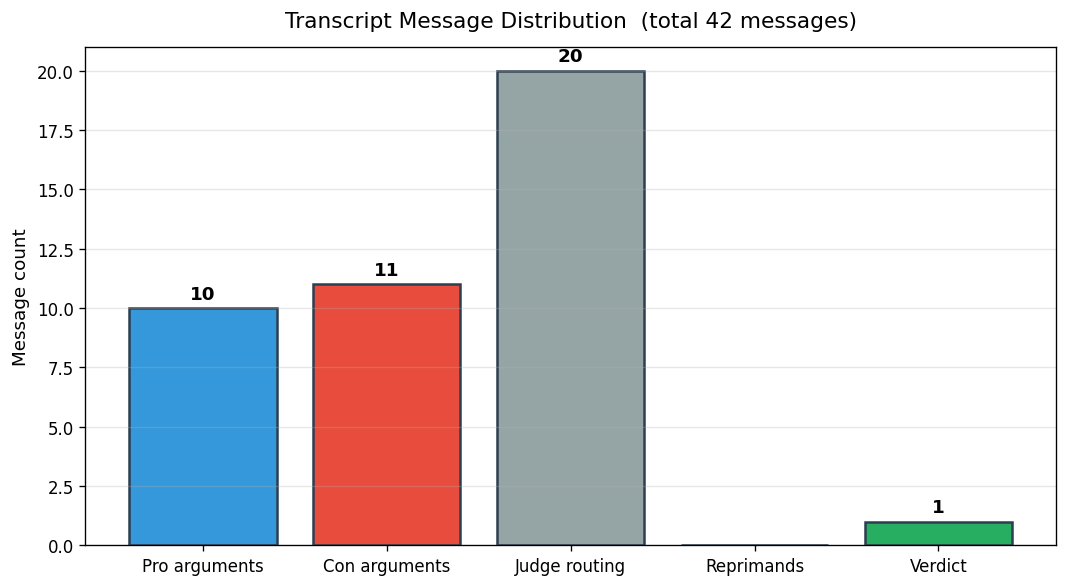

saved -> ../assets/message_distribution.png


In [8]:
from collections import Counter

counts = Counter(m.get('message_type', 'unknown') for m in DATA['transcript'])
print('Message type counts:', dict(counts))

labels = ['Pro arguments', 'Con arguments', 'Judge routing', 'Reprimands', 'Verdict']
values = [
    sum(1 for m in DATA['transcript'] if m.get('message_type') == 'argument' and m.get('agent_id') == 'Agent_Pro'),
    sum(1 for m in DATA['transcript'] if m.get('message_type') == 'argument' and m.get('agent_id') == 'Agent_Con'),
    counts.get('routing', 0),
    counts.get('reprimand', 0),
    counts.get('verdict', 0),
]
colors = ['#3498DB', '#E74C3C', '#95A5A6', '#F39C12', '#27AE60']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, values, color=colors, edgecolor='#2C3E50', linewidth=1.5)
for bar, val in zip(bars, values, strict=False):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.4, str(val),
                ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Message count', fontsize=11)
ax.set_title(f'Transcript Message Distribution  (total {len(DATA["transcript"])} messages)', fontsize=13, pad=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(ASSETS / 'message_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"saved -> {ASSETS / 'message_distribution.png'}")

## 7 — Summary

| Metric | Value |
|---|---|
| Topic | Will artificial intelligence replace human jobs? |
| Rounds | 10 |
| Date | 2026-05-28 |
| Provider / model | Anthropic · `claude-sonnet-4-6` |
| Winner | **Agent_Con** |
| Final scores | Agent_Pro 71 · **Agent_Con 73** |
| Total gated calls | 121 |
| Total tokens | 223,090 (144,569 in / 78,521 out) |
| Real estimated cost | **$1.6115 USD** |
| Free-tier reference | 3-round Gemini Flash Lite smoke: 34 calls · 37,049 tokens · **$0.0227** |

### Key observations

1. **Narrowest margin yet observed** (73 vs 71). Sonnet's nuanced scoring reflects the close-fought nature of the debate; previous Gemini runs produced wider final spreads (e.g. 89 vs 85).

2. **Round-1 citation gap was decisive** — the verdict prose quotes Pro citation 0.45 vs Con 0.78, a 15-point evidentiary gap Pro never fully closed. Pro's R2 (0.84 vs 0.80) was its only outright win; from R8 onward Con's closing surge sealed the verdict.

3. **API costs are gated, captured, and reported** — every figure above traces to `response.usage` on real API calls (Bug #1's gatekeeper-side double-retry was eliminated; Bug #2's runner-exit recovery survives transient subprocess failures).

4. **Data caveat surfaced** — the transcript JSON doesn't currently serialize per-round `PersuasionScore` objects (the judge keeps them in `_scores` as in-process state). The per-round chart plots only the rounds Sonnet quoted by name in the verdict prose; a future enhancement would dump the judge's `_scores` to the transcript so the per-dimension chart can be fully populated.